# Climate-driven Geohazards: Heavy Rainfall and Seismicity (EPOS &times; ECMWF)

### EPOS Open Science Summer School 2026 &mdash; *Interlinking Research Infrastructures: A Focus on Geoscience and Climate*


**Author:** Juliano Ramanantsoa &mdash; physical oceanographer / Earth-system data scientist, University of Bergen  
**Contact:** heriniaina.j.ramanantsoa@uib.no  
**Course:** EPOS Open Science Summer School 2026 &mdash; Lecture 1  
**Companion module:** `epos_school_function.py` (place next to this notebook)

&copy; 2026 Juliano Ramanantsoa, University of Bergen.

**Licence &mdash; Creative Commons Attribution 4.0 International (CC BY 4.0).**
You may share and adapt this material for any purpose, including teaching, provided you give
appropriate credit. The accompanying source code is additionally released under the **MIT Licence**.
Full texts: <https://creativecommons.org/licenses/by/4.0/> and <https://opensource.org/licenses/MIT>.

> **Scientific scope.** This notebook is a *retrospective screening and teaching* tool &mdash; **not** a
> prediction or early-warning system. The climate&ndash;seismicity link is treated as a rate-modulation
> **hypothesis** (well supported for Himalayan hydrological loading; weaker elsewhere). The
> `probable_climate_interaction` flag is a hypothesis generator, **not** evidence of causation.
> Limitations are documented in the closing references section.

---


## EPOS - ECMWF: Climate-driven seismic workflow

This notebook is configured for a clean teaching environment named **`epos_school`**.

**Workflow summary**

1. Load and flag candidate seismic events from an EPOS/FDSN catalogue.
2. Validate selected events with waveform data and STA/LTA triggering.
3. Retrieve ERA5 precipitation from the Copernicus Climate Data Store.
4. Classify monsoon severity using absolute precipitation bands.
5. Anchor each event in a 30-year ERA5 climatology using a z-score.
6. Save all outputs in a reproducible multimodal archive.


## Before running the notebook: student setup

Run these commands **once** in Terminal, Anaconda Prompt, or Miniforge Prompt from the folder containing this notebook.

### Mac and Windows

```bash
conda env create -f environment.yml
conda activate epos_school
python -m ipykernel install --user --name epos_school --display-name "Python (epos_school)"
python install_test.py
jupyter notebook
```

In Jupyter, choose:

```text
Kernel → Change Kernel → Python (epos_school)
```

If the environment already exists, update it instead:

```bash
conda env update -n epos_school -f environment.yml --prune
```


In [ ]:
# This cell shows the exact environment used by the notebook.
# You do not need to run it if the file environment.yml is already present in the folder.

from pathlib import Path

Path("environment.yml").write_text("""name: epos_school
channels:
  - conda-forge
dependencies:
  - python=3.11
  - numpy<2
  - pandas
  - matplotlib
  - scipy
  - obspy
  - xarray
  - cftime
  - netcdf4
  - h5netcdf
  - cdsapi>=0.7
  - tqdm
  - jupyterlab
  - notebook
  - ipykernel
""")

print("environment.yml written in the current notebook folder")


## Copernicus CDS API setup for ERA5

ERA5 download cells need a personal CDS token stored in a file named `.cdsapirc` in your home folder.

### Mac / Linux

```bash
cat > ~/.cdsapirc <<'EOF'
url: https://cds.climate.copernicus.eu/api
key: 123456:abcdefghijk-123-abcdefghijk
EOF
chmod 600 ~/.cdsapirc
```

### Windows PowerShell

```powershell
@"
url: https://cds.climate.copernicus.eu/api
key: YOUR-PERSONAL-ACCESS-TOKEN
"@ | Set-Content "$env:USERPROFILE\.cdsapirc"
```

Keep the token private. Before downloading ERA5, students must also accept the relevant dataset terms on the CDS website.


In [1]:
# Environment and CDS credential check

from pathlib import Path
import sys

required_imports = []

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])

import numpy as np
import pandas as pd
import xarray as xr
import cftime
import netCDF4
import cdsapi
from obspy import UTCDateTime, Trace
from obspy.clients.fdsn import Client

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("cftime:", cftime.__version__)
print("netCDF4:", netCDF4.__version__)
print("ObsPy: import OK")

cds_file = Path.home() / ".cdsapirc"
if cds_file.exists():
    print("CDS API file found:", cds_file)
else:
    print("CDS API file not found yet. ERA5 download cells will not work until ~/.cdsapirc is created.")

print("Environment check complete")


Python executable: /opt/anaconda3/envs/epos_clean/bin/python
Python version: 3.11.15
numpy: 1.26.4
pandas: 3.0.3
xarray: 2026.4.0
cftime: 1.6.5
netCDF4: 1.7.4
ObsPy: import OK
CDS API file found: /Users/juliano/.cdsapirc
Environment check complete


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
# EPOS and ECMWF: Seismic Events with Climate Context

## Description: 
             The script processes earthquake event data from EPOS Platform, flags events
             potentially influenced by climate interactions, fetches available seismic
             waveforms for these flagged events from different platform (GFZ), performs P/T phase
             picking using the STA/LTA algorithm (Optional). It then integrates
             ECMWF (ERA5) cumulative precipitation data for the identified events
             to assess potential connection with monsoon conditions.
             Finally, it saves all relevant outputs into a single
             multimodal pickle file for comprehensive data archiving.
             
### Technical Objectives: 
             Access to ECMWF data platform, and retrieve climate variables.

### Target Audience: 
             Students of seismology, geophysics, environmental science.
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

## Set up your environment (do this once, before class)

This notebook needs a few scientific packages. Install them **once**, then launch Jupyter
from that environment and select the kernel **Python (epos_school)**.

**Recommended - conda (handles the Cartopy / ObsPy binaries cleanly):**

```bash
conda create -n epos_school -c conda-forge python=3.11 \
    numpy pandas matplotlib xarray netcdf4 cftime cartopy obspy cdsapi tqdm \
    jupyterlab ipykernel
conda activate epos_school
python -m ipykernel install --user --name epos_school --display-name "Python (epos_school)"
```

**Alternative - pip (in a fresh virtual environment):**

```bash
python -m venv epos_school && source epos_school/bin/activate    # Windows: epos_school\Scripts\activate
pip install numpy pandas matplotlib xarray netCDF4 cftime cartopy obspy cdsapi tqdm jupyterlab ipykernel
python -m ipykernel install --user --name epos_school --display-name "Python (epos_school)"
```

Then place `epos_school_function.py` and `epos_ecmwf_workflow_elevated.png` **next to this
notebook**, and your earthquake CSV inside `epos_data/`. `Cartopy` provides the land basemap for
the maps; on first use it downloads small Natural Earth files (needs internet once).

> Do **not** `pip install` from inside the notebook - mixing pip/conda mid-session can break the
> NumPy / NetCDF binaries. Install in the terminal, once.


In [2]:
# Core packages for the EPOS × ECMWF workflow

import os
import pickle
import pathlib
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cftime
import netCDF4
import cdsapi
from tqdm import tqdm

from obspy import UTCDateTime, Trace
from obspy.clients.fdsn import Client
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# Local helper shipped with this notebook package.
# It provides the styled Map / time-series / seismogram helpers used below.
from epos_school_function import *

set_epos_style()   # apply the shared figure theme to every plot

print("Imports OK — using the EPOS school environment.")


Imports OK — using the EPOS school environment.


In [3]:
# Functions ----------------------------------------------------------------
#
# The seismogram plotter now lives in epos_school_function.py (plot_seismogram),
# so every figure shares one house style. We alias it to the name used below.

_quick_plot = plot_seismogram


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 1. Load and flag events
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [4]:
# Documentation for this section:
# ------------------------------
#
# This section focuses on loading earthquake catalog data from EPOS (.csv file) and applying
# filters to identify events that might exhibit a "probable climate interaction."
# This flagging is based on three primary criteria: event depth, epicentral
# region, and time of year (monsoon season).

# This initial filtering aims to pre-select earthquakes that are shallow,
# occur in regions known for significant hydrological cycles (like the Himalayas
# and surrounding areas), and happen during the peak monsoon season. These
# conditions are hypothesized by various studies to potentially influence
# seismicity through mechanisms such as surface loading, pore-pressure changes,
# and altered crustal stress states due to water mass variations.
#
# 1.1. Data Loading and Initial Cleaning:
#      The script starts by loading a CSV file containing earthquake parameters.
#      "Origin time" is converted to datetime objects, and rows with missing
#      critical information (Origin time, Epicentre latitude, Epicentre longitude, Depth)
#      are removed to ensure data quality for subsequent analysis.
#
# 1.2. Marking Shallow Events (`is_shallow`):
#      Events with a depth less than or equal to 20 km (20000 meters) are flagged
#      as 'shallow'. Shallow earthquakes are more susceptible to surface processes
#      compared to deeper events.
#      • Bettinelli et al., 2008, Nature Geoscience (DOI:10.1038/ngeo251)
#      • Craig et al., 2017, Nature Communications (DOI:10.1038/ncomms15696)
#      These studies provide strong evidence for hydrological/surface loading
#      effects influencing seismicity at these depths.
#
# 1.3. Marking Events in Climate-Sensitive Regions (`is_climate_region`):
#      A predefined list of keywords (e.g., "nepal", "myanmar", "sumatra") is used
#      to identify events occurring in regions recognized for their strong
#      climate-tectonic interactions, particularly those affected by large
#      seasonal hydrological changes (e.g., monsoon).
#      Regions and keywords justified by:
#      • Bettinelli et al., 2008, Nature Geoscience (DOI:10.1038/ngeo251)
#      • Amos et al., 2014, Nature (DOI:10.1038/nature13202)
#      • Pérez-Guillén et al., 2022, GRL (DOI:10.1029/2022GL100746)
#      • Mayer et al., 2014, Earth Surf Dyn (DOI:10.5194/esurf-2-455-2014)
#      • Sun et al., 2020, JGR (DOI:10.1029/2019JB018823)
#
# 1.4. Monsoon Season Definition (`is_monsoon`):
#      The monsoon season is defined for events occurring between May and September
#      (inclusive, months 5 to 9). This period broadly corresponds to the South Asian
#      summer monsoon, which brings significant precipitation and hydrological loading.
#      • The South Asian (Indian) summer monsoon typically spans June–September
#        (e.g., Turner & Annamalai, 2012, Nature Communications, DOI:10.1038/ncomms1794)
#      • Some Himalayan regions experience early pre-monsoon rain from May onward
#        (e.g., Bookhagen & Burbank, D.W., 2010, Nature Geoscience, DOI:10.1038/ngeo907)
#      • Multiple studies have shown earthquake rates and stresses may correlate with
#        monsoon precipitation and its lagged effects on groundwater, snowmelt, or pore pressure
#        (Bettinelli et al., 2008, Nature Geoscience, DOI:10.1038/ngeo251;
#        Amos et al., 2014, Nature, DOI:10.1038/nature13202)
#
# 1.5. Probable Climate Interaction Flag (`probable_climate_interaction`):
#      An event is flagged with "probable_climate_interaction" if all three conditions
#      (is_shallow, is_climate_region, and is_monsoon) are met.
#      It's crucial to note that this "probable" flag serves as a preliminary filter
#      and a hypothesis generator. Actual causality in climate-tectonic interactions
#      is highly complex and involves factors not directly observed here, such as:
#      - Lagged effects: Groundwater percolation and pore-pressure diffusion can have
#        delays ranging from days to months depending on the specific geology
#        (Bettinelli et al., 2008).
#      - Interplay of phenomena: Interactions between snowmelt, direct precipitation,
#        and antecedent water load.
#      - Fault criticality: The existing state of stress on a fault system also plays a
#        significant role, which is not accounted for in this simple model.
#      Therefore, this flag is a necessary but not sufficient indicator and should be
#      treated as a starting point for more in-depth investigations.
# ----------------------------------------------------------------------------

In [5]:
# Construct the full path to the CSV file
csv_path = os.path.join(os.getcwd(), "epos_data", "Parameters of modern earthquakes (1998-present) - FDSN event-2.csv")


# Load the CSV data into a pandas DataFrame
original_df = pd.read_csv(csv_path) # Store the original for pickling


# Create a working copy of the DataFrame for processing
df = original_df.copy()


# Convert the "Origin time" column to datetime objects. 'coerce' will turn
# unparseable dates into NaT (Not a Time).
df["Origin time"] = pd.to_datetime(df["Origin time"], errors="coerce")


# Drop rows where critical columns have missing values (NaN/NaT), ensuring
# complete data for analysis.
df = df.dropna(subset=["Origin time", "Epicentre latitude", "Epicentre longitude", "Depth"])

# Define keywords for identifying climate-sensitive regions. These are based on
# geographical areas known for significant hydrological cycles and seismic activity.
region_keywords = [
    "nepal", "myanmar", "xizang", "hindu kush", "tajikistan", "sumatra",
    "india", "sikkim", "china", "pamir"
]

# Create a boolean column 'is_shallow': True if Depth is 10 km or less (10000 metres).
df["is_shallow"] = df["Depth"] <= 10000   # shallow crust: Depth <= 10 km (10000 m)


# Create a boolean column 'is_climate_region': True if any of the region_keywords
# are found in the 'Epicentral area' (case-insensitive).
df["is_climate_region"] = df["Epicentral area"].str.lower().apply(lambda area: any(kw in area for kw in region_keywords))

# Extract the month from the 'Origin time'
df["month"] = df["Origin time"].dt.month

# Create a boolean column 'is_monsoon': True if the month falls between May (5) and September (9).
df["is_monsoon"] = df["month"].between(5, 9)

# Create a boolean column 'probable_climate_interaction': True if an event
df["is_big_mag"] = pd.to_numeric(df["Magnitude value"], errors="coerce") >= 4.5

df["probable_climate_interaction"] = (
    df["is_shallow"]        &        # depth ≤ 10 km
    df["is_climate_region"] &        # in target hydrological belt
    df["is_monsoon"]        &        # May–Sep
    df["is_big_mag"]                 # Mw ≥ 4.5  ← NEW
)

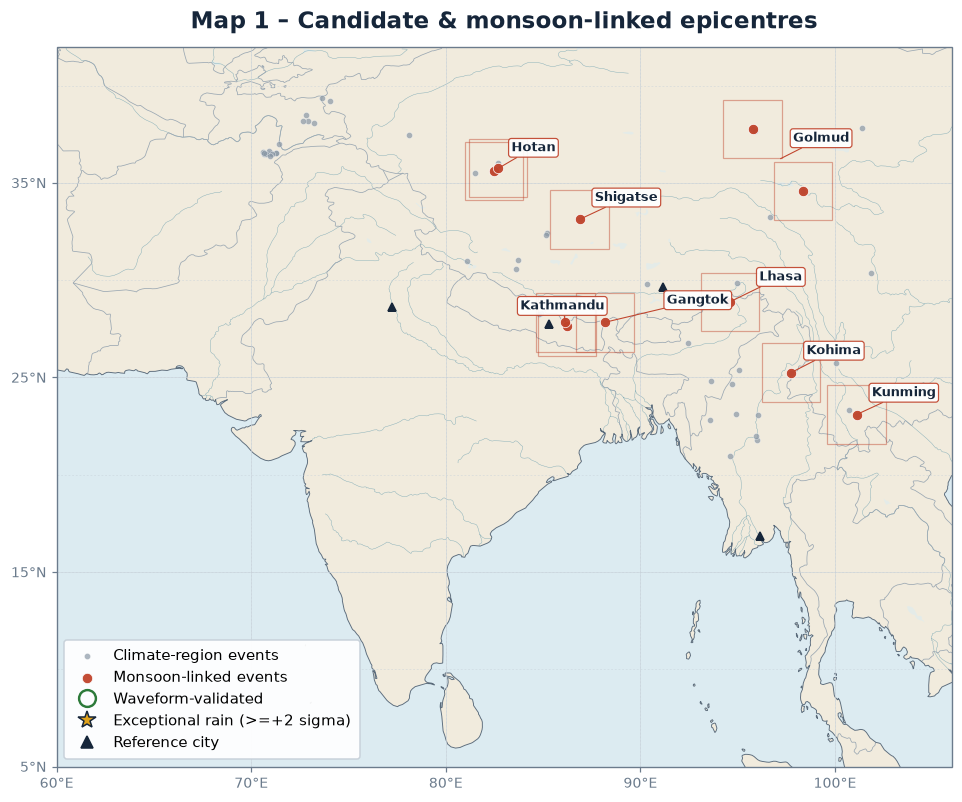

<GeoAxes: title={'center': 'Map 1 – Candidate & monsoon-linked epicentres'}>

In [6]:
# --------------------------------------------------------------------------------------------------
# 📍  Generic epicentre plotting helper 1
# --------------------------------------------------------------------------------------------------


plot_epicentre_map(df, title="Map 1 – Candidate & monsoon-linked epicentres")

#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 2. For events with waveforms, plot, and tabulate
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [7]:
# Documentation for this section:
# ------------------------------

# This section iterates through the events flagged as "probable_climate_interaction"
# to attempt to retrieve seismic waveform data, plot the waveforms, and
# tabulate the results.

# Optional: perform automated P- and S-phase
# (or generally, onset and end of strong shaking) picking using the Short-Term
# Average/Long-Term Average (STA/LTA) algorithm. The STA/LTA algorithm is a common method for automated
# detection of seismic phases.

# Seismograms provide the ground motion recordings necessary to identify
# earthquake arrivals. 
#
# 2.1. FDSN Client Initialization:
#      An ObsPy FDSN client is initialized, pointing to the GFZ data center.
#      ObsPy is a powerful Python toolbox for seismology, providing tools to
#      access seismic data from various global data centers.
#      • ObsPy Project (https://docs.obspy.org/)
#
# 2.2. Iterating through Flagged Events:
#      The script loops through each earthquake event previously flagged with
#      'probable_climate_interaction'. For each event, it attempts to:
#
#      a. Find Nearby Stations:
#         Uses `client.get_stations` to query for broadband (channel "BH?")
#         seismic stations within a 2-degree radius of the earthquake's
#         epicenter. `level="response"` ensures that instrument response
#         information is also retrieved, which is crucial for proper data
#         processing.
#
#      b. Fetch Waveforms:
#         If a suitable station is found, `client.get_waveforms` is used to
#         download 30 minutes of waveform data starting from the earthquake's
#         origin time. This window is expected to contain the P-wave arrival
#         and subsequent phases.
#
#      c. Pre-processing Waveforms: (Optional)
#         - `st.detrend("demean")`: Removes the mean from the trace,
#           essential for stable STA/LTA calculations.
#         - `st.filter("bandpass", freqmin=0.02, freqmax=2)`: Applies a
#           bandpass filter to remove very low-frequency noise (e.g., tides)
#           and high-frequency noise, focusing on the frequency range typical
#           for teleseismic earthquake signals.
#
#      d. STA/LTA Phase Picking: (Optional)
#         - `classic_sta_lta(tr.data, nsta, nlta)`: Computes the STA/LTA ratio.
#           The STA/LTA algorithm works by comparing the average amplitude of
#           the seismic signal over a short-term window (STA) to that over a
#           long-term window (LTA). A significant increase in this ratio indicates
#           an arrival.
#           • STA (Short-Term Average) window: `nsta` samples (here, 1 second).
#           • LTA (Long-Term Average) window: `nlta` samples (here, 20 seconds).
#           The choice of these window lengths depends on the signal characteristics
#           and noise levels.
#           • Trani, D., 2010. Automated Real-time Detection of Seismic Events.
#             (Masters thesis, Politecnico di Torino)
#           • Allen, R. V., 1978. Automatic earthquake recognition and timing
#             from single traces. Bulletin of the Seismological Society of America,
#             68(5), 1521-1532.
#         - `trigger_onset(cft, 3, 1)`: Applies a threshold-based trigger to the
#           STA/LTA characteristic function (`cft`). It identifies the start (P-phase)
#           when the `cft` crosses an 'on' threshold (here, 3) and the end (T-phase/end of strong shaking)
#           when it falls below an 'off' threshold (here, 1).
#           The `on_of` variable contains a list of [start_sample, end_sample] pairs.
#
#      e. Arrival Time Calculation: (Optional)
#         Converts the detected sample indices (P-sample, T-sample) into
#         UTCDateTime objects using the trace's start time and sampling rate.
#
#      f. Plotting Waveforms and Picks:
#         Uses Matplotlib to plot the raw seismic trace.
#         A red shaded region highlights the detected earthquake window.
#         This visual representation helps in validating the automated picks.
#
#      g. Tabulating Event Information:
#         Key details about the event, including its origin time, epicentral
#         information, magnitude, depth, and the newly picked P/T phase times,
#         along with the station and channel used, are appended to `event_table`.
#         This forms a structured summary of the processed events.
#
# 2.3. Error Handling:
#      A `try-except` block is used to gracefully handle cases where waveform
#      data cannot be fetched (e.g., no station found, network issues) and prints
#      an informative error message.
# ----------------------------------------------------------------------------


=== Event 8 at (34.58, 98.36) on 2021-05-21T18:04:14.500000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 11 at (33.12, 86.87) on 2020-07-22T20:07:19.200000Z ===
   Using station: XF.ST23A (BHN)
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 12 at (35.60, 82.49) on 2020-06-25T21:05:18.400000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 27 at (27.62, 86.21) on 2015-05-12T07:36:52.900000Z ===
   Using station: IO.EVN (BHE)


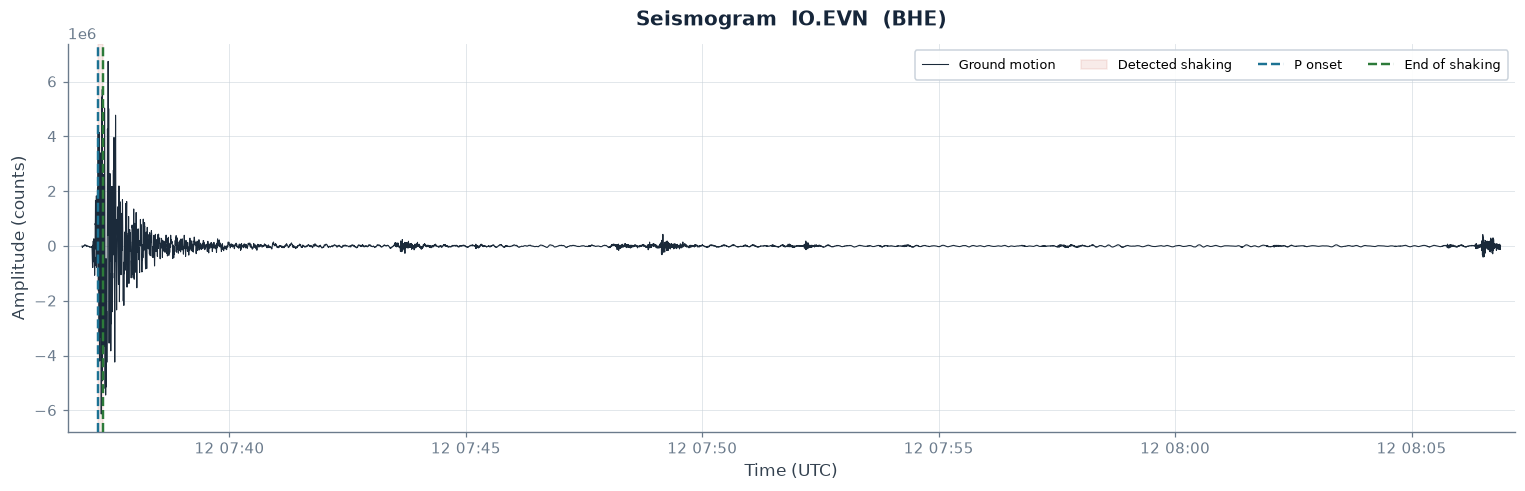


=== Event 28 at (27.83, 86.14) on 2015-05-12T07:05:18.700000Z ===
   Using station: IO.EVN (BHE)


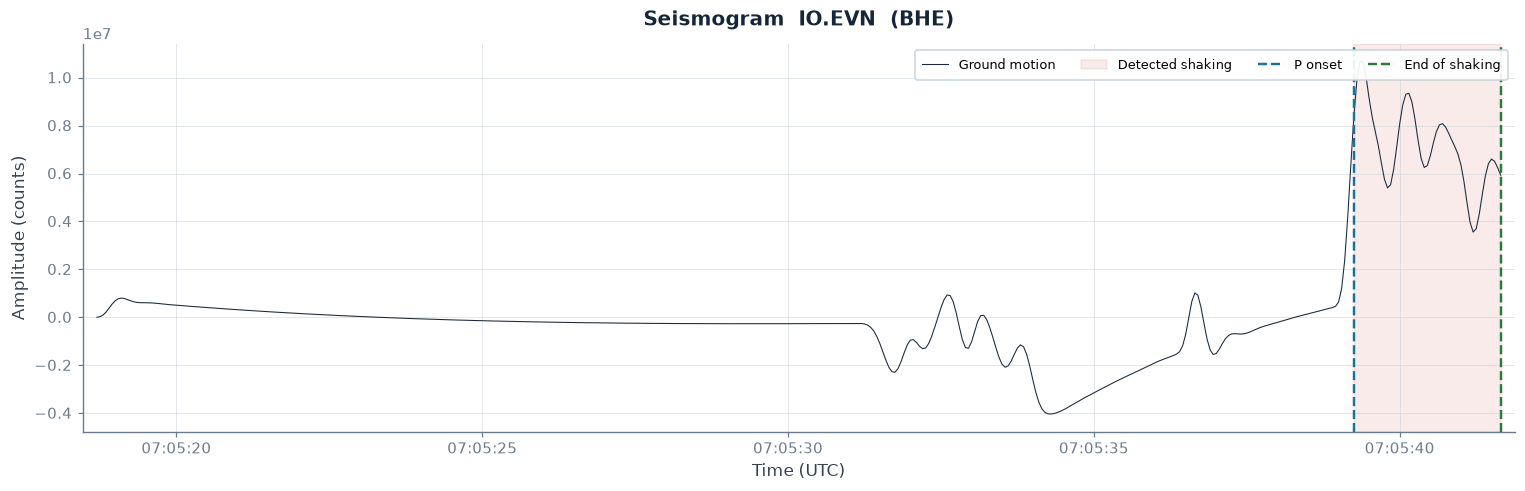


=== Event 37 at (35.76, 82.68) on 2012-08-12T10:47:05.300000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 38 at (27.83, 88.17) on 2011-09-18T12:40:47.300000Z ===
   Using station: IO.EVN (BHE)
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 46 at (37.76, 95.76) on 2009-08-28T01:52:06.600000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 54 at (25.25, 97.75) on 2008-08-21T12:24:33.200000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 58 at (23.09, 101.11) on 2007-06-02T21:34:57.500000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed respo

,Event idx,Origin time,Epicentral area,Epicentre lat,Epicentre lon,Magnitude,Depth,is_shallow,is_climate_region,is_monsoon,P_phase_time,T_phase_time,station,channel,monsoon_total_precipitation_mm,monsoon_cumulative_precipitation_mm,seismic_trace_data,seismic_trace_stats
0,27,2015-05-12 07:36:52.900,nepal,27.62,86.21,6.3,2000.0,True,True,True,2015-05-12T07:37:12.850000Z,2015-05-12T07:37:19.700000Z,IO.EVN,BHE,None,[],"[-225.0516629138202, -1649.7843158985568, -582...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."
1,28,2015-05-12 07:05:18.700,nepal,27.83,86.14,7.1,2000.0,True,True,True,2015-05-12T07:05:39.250000Z,2015-05-12T07:05:41.650000Z,IO.EVN,BHE,None,[],"[3561.9868074543374, 26261.181560244913, 93194...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."


In [8]:
# Initialize an FDSN client to fetch seismic data from the GFZ data center.
client = Client("GFZ")

# Initialize an empty list to store dictionaries of event data, which will
# later be converted into a pandas DataFrame. This will also hold raw seismic data.

waveform_ok = []
event_table = []
# Loop through each row in the DataFrame that has been flagged as having a
# "probable_climate_interaction".
for idx, row in df[df["probable_climate_interaction"]].iterrows():
    lat = row["Epicentre latitude"]
    lon = row["Epicentre longitude"]
    t0 = UTCDateTime(row["Origin time"]) # Convert pandas datetime to ObsPy UTCDateTime

    # Print header for the current event being processed for clear progress tracking.
    print(f"\n=== Event {idx} at ({lat:.2f}, {lon:.2f}) on {t0} ===")

    try:
        # ----------------------------------------------------------------------------
        # Attempt to get information about broadband (BH?) seismic stations
        # within a 2-degree radius of the event, including their response information.
        inv = client.get_stations(latitude=lat, longitude=lon, maxradius=2, channel="BH?", level="response")

        # If no stations or networks are found in the inventory, skip this event.
        if not inv or not inv.networks:
            print("   No nearby broadband station found.")
            continue # Move to the next event in the loop

        # Extract network, station, channel, and location codes from the first available station.
        # Use an empty string if location_code is None.
        net = inv[0].code
        sta = inv[0][0].code
        cha = inv[0][0][0].code
        loc = inv[0][0][0].location_code or ""

        print(f"   Using station: {net}.{sta} ({cha})")

        # ----------------------------------------------------------------------------
        # Fetch waveform data for the selected station, starting from the event's origin time and extending for 30 minutes.
        st = client.get_waveforms(network=net, station=sta, location=loc, channel=cha,
                                  starttime=t0, endtime=t0 + 60 * 30)

        # Remove the mean from the waveform data. This is a common pre-processing step to prepare data for filtering and STA/LTA.
        st.detrend("demean")

        # Apply a bandpass filter to the waveform to remove unwanted frequencies
        # (e.g., very low frequency noise like tides or high frequency cultural noise).
        st.filter("bandpass", freqmin=0.02, freqmax=2) # Explain choice of frequency

        # Select the first (and likely only) trace from the Stream object.
        tr = st[0]

        # ----------------------------------------------------------------------------
        # STA/LTA P/T picker 
        
        # Calculate the number of samples for the short-term average (STA) window (1 second).
        nsta = int(1 * tr.stats.sampling_rate)
        # Calculate the number of samples for the long-term average (LTA) window (20 seconds).
        nlta = int(20 * tr.stats.sampling_rate)

        # Compute the Characteristic Function (CFT) using the classic STA/LTA algorithm.
        cft = classic_sta_lta(tr.data, nsta, nlta)

        # Apply a trigger to the CFT to detect onsets (P-phase) and offsets (T-phase/end of strong shaking).
        # Trigger 'on' threshold is 3, 'off' threshold is 1.
        on_of = trigger_onset(cft, 3, 1)

        p_time, t_time = None, None # Initialize phase times to None (REVISED-------------------------------)

        # If any on/off pairs are detected by the trigger.
        if len(on_of) > 0:
            p_sample = on_of[0][0] # The first sample of the first detected onset.
            t_sample = on_of[0][1] # The last sample of the first detected event.

            # Calculate the UTCDateTime for the P-phase arrival.
            p_time = tr.stats.starttime + (p_sample / tr.stats.sampling_rate)
            # Calculate the UTCDateTime for the T-phase (end of strong shaking).
            t_time = tr.stats.starttime + (t_sample / tr.stats.sampling_rate)

        # ----------------------------------------------------------------------------
        # Selected waveform DataFrame index 
        waveform_ok.append(idx)                     # <-- keep the DataFrame index


        # ----------------------------------------------------------------------------
        # Plotting
        _quick_plot(tr, p_time, t_time, net, sta, cha)


        # ----------------------------------------------------------------------------
        # Table info 

        try:
            stats_dict = tr.stats.as_dict()
        except Exception:
            stats_dict = dict(tr.stats)


        # Append the processed event's information to the event_table list.
        event_entry = {
            "Event idx": idx,
            "Origin time": row["Origin time"],
            "Epicentral area": row["Epicentral area"],
            "Epicentre lat": lat,
            "Epicentre lon": lon,
            "Magnitude": row.get("Magnitude value", None), # Use .get to safely retrieve Magnitude value, defaulting to None if not present.
            "Depth": row["Depth"],
            "is_shallow": row["is_shallow"],
            "is_climate_region": row["is_climate_region"],
            "is_monsoon": row["is_monsoon"],
            "P_phase_time": p_time,
            "T_phase_time": t_time, # (REVISED-------------------------------)
            "station": f"{net}.{sta}",
            "channel": cha,
            "monsoon_total_precipitation_mm": None, # Placeholder for ECMWF data, will be filled later
            "monsoon_cumulative_precipitation_mm": [], # Placeholder for cumulative sum
            "seismic_trace_data": tr.data.tolist(), # Store raw data as list (for pickling compatibility)
            "seismic_trace_stats": stats_dict # Store trace stats as dict (for pickling compatibility)
        }
        event_table.append(event_entry)
        # waveform_ok.append(idx)        # <-- keep the DataFrame index

    except Exception as e:
        # Catch any exceptions that occur during waveform fetching or processing
        # and print an informative error message.
        print(f"   Could not fetch seismogram for this event: {e}")
        # Optionally, add an entry to the table indicating failure, if needed
        # event_table.append({"Event idx": idx, "Error": str(e), ...})

# 3. Produce DataFrame summary (preliminary)
event_df = pd.DataFrame(event_table)

# If no waveforms were retrieved (e.g. offline, or no nearby station), keep the
# expected columns so the downstream cells run as harmless no-ops instead of
# raising KeyError.
_EXPECTED_EVENT_COLS = [
    "Event idx", "Origin time", "Epicentral area", "Epicentre lat", "Epicentre lon",
    "Magnitude", "Depth", "is_shallow", "is_climate_region", "is_monsoon",
    "P_phase_time", "T_phase_time", "station", "channel",
    "monsoon_total_precipitation_mm", "monsoon_cumulative_precipitation_mm",
    "seismic_trace_data", "seismic_trace_stats",
]
if event_df.empty:
    event_df = pd.DataFrame(columns=_EXPECTED_EVENT_COLS)
    print("No waveforms retrieved -> event_df is empty (downstream cells will no-op).")
print("\nValidated earthquake events with detected P/T phases (preliminary):")
display(event_df)


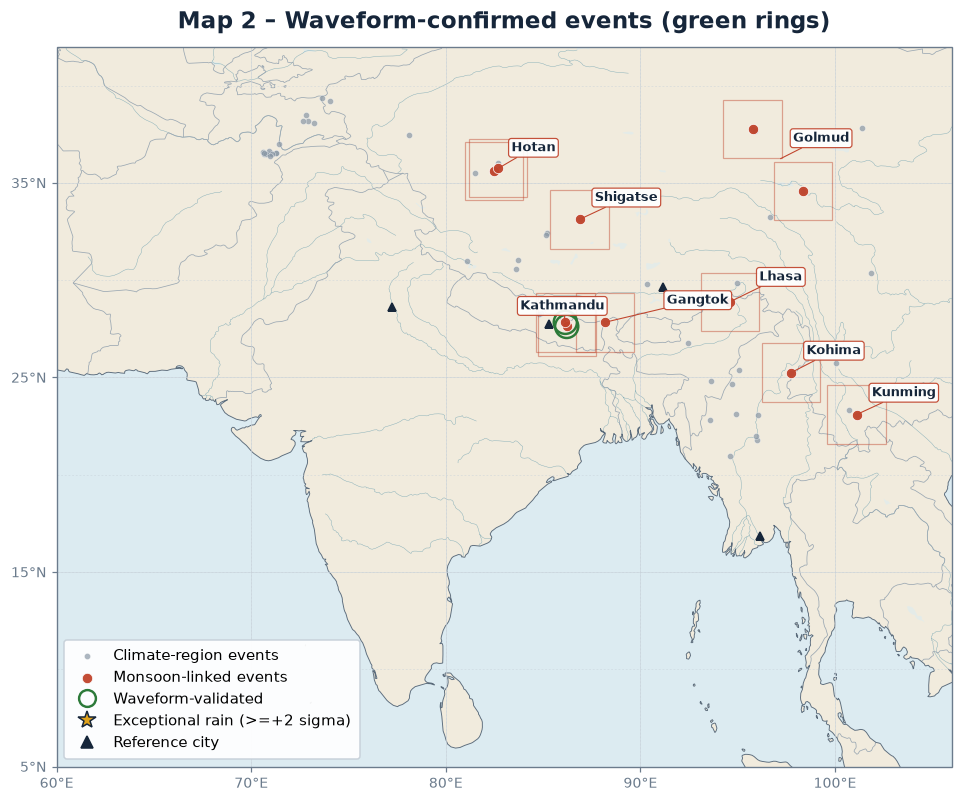

<GeoAxes: title={'center': 'Map 2 – Waveform-confirmed events (green rings)'}>

In [9]:
# ----------------------------------------------------------------------------
# 📍  Generic epicentre plotting helper 2
# ----------------------------------------------------------------------------

plot_epicentre_map(df,
                   highlight_idx=waveform_ok,
                   title="Map 2 – Waveform-confirmed events (green rings)")

#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 3. Retrieve and analyze ECMWF data for monsoon events: May–Sep precipitation
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

**What this section does.** For every waveform-validated event we download the ERA5
*total precipitation* field over a small box centred on the epicentre and turn it into two
numbers the rest of the notebook can use.

**Step by step**
- **Box.** A `3 deg x 3 deg` window (`lat +/- 1.5`, `lon +/- 1.5`) around the epicentre - large
  enough to capture the regional monsoon signal, small enough to stay local.
- **Variable & period.** `total_precipitation` (ERA5 monthly means) for the monsoon months
  **May-September** of the event year.
- **Units.** ERA5 stores precipitation in **metres of water**; we multiply by **1000 -> mm**.
- **Two outputs per event:** the **seasonal total** (`monsoon_total_precipitation_mm`, summed over
  the box and the five months) and the **month-by-month cumulative curve**
  (`monsoon_cumulative_precipitation_mm`), which shows how the wet season built up.

> **Note.** ERA5 precipitation is a *model* field constrained by observations, not a rain-gauge
> reading. Over steep Himalayan terrain treat absolute values as indicative, and prefer the
> standardised anomaly (Section 5) when comparing one place to another. Downloads require a
> configured `~/.cdsapirc`; files are cached in `epos_data/era5_data/` so each event is fetched once.


In [10]:
# ------------------------------
# Documentation for this section:
# ------------------------------

# This section focuses on retrieving monthly total precipitation data from the
# ECMWF ERA5 reanalysis dataset for a region and time period relevant to each
# validated earthquake event. This data will be used to assess the precipitation
# conditions during the monsoon season when the seismic event occurred.

#
# To investigate if a seismic event coincides with an "exceptional monsoon event",
# we need reliable precipitation data. ERA5 is the fifth generation ECMWF
# reanalysis for the global climate and weather, providing hourly estimates
# of a large number of atmospheric, land, and oceanic climate variables.
# Monthly means are used here for a broader seasonal assessment.
#
# 4.1. Setup for ECMWF Data Retrieval:
#      - `cdsapi.Client()`: Initializes the client to interact with the
#        Copernicus Data Store (CDS). This requires prior setup of the
#        `.cdsapirc` file in the user's home directory with API credentials.
#      - `OUT_DIR_ERA5`: A specific directory is created to store the
#        downloaded NetCDF files, organized by event.
#
# 4.2. Iterating through Validated Events for Data Download:
#      The script iterates through the `event_df` (which contains events
#      for which seismograms were successfully retrieved and processed).
#      For each event, it dynamically constructs a request for ERA5 data:
#
#      a. Area of Interest (`AREA`):
#         A bounding box is defined around the earthquake's epicenter.
#         A buffer of +/- 1.5 degrees in latitude and longitude is used
#         to capture the regional precipitation patterns relevant to the event.
#         This dynamic approach ensures that the downloaded data is localized
#         to the vicinity of each specific earthquake.
#
#      b. Time Period (`year`, `month`):
#         The request is for the specific `year` of the earthquake's origin
#         and the `monsoon_months` (May through September, i.e., 05 to 09).
#         This aligns with the `is_monsoon` flag defined earlier and ensures
#         that we capture the full seasonal precipitation leading up to and
#         during the event.
#
#      c. Variable (`total_precipitation`):
#         `"total_precipitation"` is selected as the primary variable. This
#         represents the accumulated precipitation over the month (in meters).
#         It is the most direct measure for assessing monsoon intensity.
#         Other variables like wind components (`10m_u_component_of_wind`,
#         `10m_v_component_of_wind`) could also be requested for more detailed
#         monsoon analysis (e.g., wind circulation patterns) but are omitted
#         here for simplicity and focus on precipitation.
#
#      d. Data Format (`netcdf`):
#         The data is requested in NetCDF format, a common self-describing
#         format for scientific data, easily handled by libraries like `xarray`.
#
#      e. Error Handling and Skipping:
#         `try-except` blocks are used to catch any issues during the download.
#         The script also checks if a file for a specific event has already
#         been downloaded to avoid redundant requests.
#
# 4.3. Analysis of Downloaded Precipitation Data:
#      After downloading, the NetCDF file for each event is opened using `xarray`.
#      The `total_precipitation` values (which are in meters) are converted to
#      millimeters for easier interpretation. Both the total sum across the
#      monsoon months and the *cumulative sum* of monthly values are calculated.
#      The cumulative sum provides insight into the rainfall progression
#      throughout the monsoon season.
#
# 4.4. Defining "Exceptional Monsoon Event":
#      Based on meteorological literature (e.g., India Meteorological Department classifications):
#      - **Daily Extreme Rainfall**: While this script uses monthly data, daily thresholds
#        are often cited, e.g., "Very Heavy Rain" (124.5-244.4 mm/day), "Extremely Heavy Rain"
#        (>= 244.5 mm/day), "Exceptionally Heavy Rainfall" (a value near the highest recorded
#        rainfall for the month/season, exceeding 120 mm in a day). These are not directly
#        applicable to monthly means but inform the severity context.
#      - **Seasonal/Interannual Anomalies**: For a seasonal monsoon (like May-September
#        total precipitation in a region) to be considered "exceptional," it typically involves
#        comparison to a long-term climatological average (e.g., 30-year mean).
#        - **Excess Monsoon**: Often defined as a percentage departure of realized
#          rainfall from the long-period average (LPA) of +20% or more.
#        - **Above Normal**: When the total rainfall is greater than the LPA plus one
#          standard deviation (LPA + $\sigma$).
#        - **Below Normal / Deficient**: When the total rainfall is less than the LPA minus one
#          standard deviation (LPA - $\sigma$), or a percentage departure of -20% or more.
#      Therefore, the `monsoon_total_precipitation_mm` and `monsoon_cumulative_precipitation_mm`
#      values in the `event_df` provide the observed precipitation for the event's monsoon period.
#      To classify it as "exceptional," these values must be quantitatively compared against
#      historical means and standard deviations for the specific geographic area.
# ----------------------------------------------------------------------------
# ----------------------------------------------------------------------------

In [11]:
# ----------------------------------------------------------------------------
# earthquake epicentre (lat, lon)
#           └──> 3×3° box
#                     └──> ERA-5 monthly tp grids (May-Sep)
#                                 ├── sum over box (mm)
#                                 └── cumulative vector
# ----------------------------------------------------------------------------

In [12]:
# ----------------------------------------------------------------------------
# Copernicus CDS client (modern endpoint).
#
# Credentials are read from ~/.cdsapirc, exactly as described in the setup cell
# above. Create that file ONCE with the *current* CDS endpoint and your personal
# access token (the retired /api/v2 endpoint and old UID:KEY tokens no longer work):
#
#     url: https://cds.climate.copernicus.eu/api
#     key: <your-personal-access-token>
#
# This cell does NOT hard-code any key. If credentials are missing it sets
# cds_client = None so the ERA5 cells below skip gracefully instead of crashing,
# and you can still inspect any NetCDF files already cached on disk.
# ----------------------------------------------------------------------------
import os
import cdsapi

cds_client = None
try:
    # cdsapi.Client() reads ~/.cdsapirc (or the CDSAPI_URL / CDSAPI_KEY
    # environment variables if you set them in your shell instead).
    cds_client = cdsapi.Client()
    print("CDS client ready (using ~/.cdsapirc).")
except Exception as e:
    print("CDS client NOT configured:", e)
    print("ERA5 download cells will be skipped. Create ~/.cdsapirc to enable them "
          "(see the 'Copernicus CDS API setup' section above).")


CDS client ready (using ~/.cdsapirc).


In [13]:
# Set up output folder for the per-event NetCDF files
OUT_DIR_ERA5 = os.path.join(os.getcwd(), "epos_data", "era5_data")
os.makedirs(OUT_DIR_ERA5, exist_ok=True)

# Monsoon months ("05" -> "09")
MONSOON_MONTHS = [f"{m:02d}" for m in range(5, 10)]

ecmwf_downloaded_files = []

for i, row in tqdm(event_df.iterrows(), total=len(event_df),
                   desc="ERA-5 download + parse"):

    event_idx = row["Event idx"]
    lat, lon  = row["Epicentre lat"], row["Epicentre lon"]
    year_str  = str(row["Origin time"].year)

    # 3x3 deg box  (North, West, South, East) -- CDS area order
    area = [lat + 1.5, lon - 1.5, lat - 1.5, lon + 1.5]

    outfile = os.path.join(
        OUT_DIR_ERA5, f"era5_event_{event_idx}_{year_str}_monsoon.nc")

    # ---- Download the NetCDF if absent and credentials are available --------
    if not os.path.exists(outfile):
        if cds_client is None:
            print(f"   (no CDS client) skipping download for event {event_idx}")
        else:
            req = {
                "product_type": "monthly_averaged_reanalysis",
                "variable": "total_precipitation",
                "year": [year_str],
                "month": MONSOON_MONTHS,
                "time": "00:00",
                "area": area,
                "data_format": "netcdf",          # modern CDS key (was "format")
                "download_format": "unarchived",  # return a plain .nc, not a .zip
            }
            try:
                cds_client.retrieve(
                    "reanalysis-era5-single-levels-monthly-means", req, outfile)
                print(f"   downloaded {outfile}")
            except Exception as e:
                print(f"   retrieve raised ({e}); will still try to read the file")

    # ---- Parse the file (pre-existing or just downloaded) -------------------
    total_mm, cumulative_mm = None, []
    if os.path.exists(outfile):
        try:
            ds = xr.open_dataset(outfile)
            if "tp" in ds and ds["tp"].size:
                # ERA-5 stores metres of water; multiply by 1000 -> mm
                total_mm = float(ds["tp"].sum() * 1000)
                # sum each month over the box, convert to mm, take running total
                space_dims = [d for d in ("latitude", "longitude") if d in ds["tp"].dims]
                monthly_series = ds["tp"].sum(dim=space_dims) * 1000
                cumulative_mm = monthly_series.cumsum().values.tolist()
                ecmwf_downloaded_files.append(outfile)
                print(f"   -> {total_mm:.1f} mm total")
            else:
                print("   'tp' variable missing or empty")
            ds.close()
        except Exception as e:
            print(f"   could not open/parse {outfile}: {e}")
    else:
        print("   file not found on disk")

    # ---- Store results back into event_df -----------------------------------
    event_df.at[i, "monsoon_total_precipitation_mm"]      = total_mm
    event_df.at[i, "monsoon_cumulative_precipitation_mm"] = cumulative_mm


ERA-5 download + parse: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 24.04it/s]

   -> 5530.8 mm total
   -> 5229.8 mm total


In [14]:
print("\nFinal validated earthquake events with ERA-5 monsoon precipitation:")
display(event_df)


Final validated earthquake events with ERA-5 monsoon precipitation:


,Event idx,Origin time,Epicentral area,Epicentre lat,Epicentre lon,Magnitude,Depth,is_shallow,is_climate_region,is_monsoon,P_phase_time,T_phase_time,station,channel,monsoon_total_precipitation_mm,monsoon_cumulative_precipitation_mm,seismic_trace_data,seismic_trace_stats
0,27,2015-05-12 07:36:52.900,nepal,27.62,86.21,6.3,2000.0,True,True,True,2015-05-12T07:37:12.850000Z,2015-05-12T07:37:19.700000Z,IO.EVN,BHE,5530.799866,"[438.68255615234375, 1496.879638671875, 2873.7...","[-225.0516629138202, -1649.7843158985568, -582...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."
1,28,2015-05-12 07:05:18.700,nepal,27.83,86.14,7.1,2000.0,True,True,True,2015-05-12T07:05:39.250000Z,2015-05-12T07:05:41.650000Z,IO.EVN,BHE,5229.846954,"[417.1142578125, 1427.8927001953125, 2715.4409...","[3561.9868074543374, 26261.181560244913, 93194...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 4.  Monsoon-Severity Rating (based on literature thresholds)
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Literature touchpoints
----------------------
• India Meteorological Department (IMD) all-India long-period average (LPA)
  for the Southwest Monsoon (Jun–Sep) ≈ **880 mm**; σ ≈ 90 mm.
  
• “Excess” monsoon years are > LPA + 20 %  (≈ 1056 mm).

• Two-sigma wet seasons (LPA + 2σ) ≈ **1060–1100 mm** can be treated as
  “exceptional” in Himalayan hydro-seismic studies (e.g., Bettinelli 2008).

We adopt the following rule-of-thumb bands for total May–Sep precipitation
inside the 3 × 3 ° box around each quake:

    ≥1100 mm   →  Exceptional (“very wet”)
    880–1100 mm→  Above-normal / Wet
    700–880 mm →  Normal
    <700 mm    →  Deficient / Dry


In [15]:
def classify_monsoon(total_mm):
    if pd.isna(total_mm):
        return "Unknown"
    if total_mm >= 1100:
        return "Exceptional"
    elif total_mm >= 880:
        return "Wet"
    elif total_mm >= 700:
        return "Normal"
    else:
        return "Dry"

In [16]:
event_df["monsoon_class"] = event_df["monsoon_total_precipitation_mm"].apply(classify_monsoon)
summary_counts = event_df["monsoon_class"].value_counts().to_dict()




print("\n──────── Climate–Seismicity Summary ────────")
for cls in ["Exceptional", "Wet", "Normal", "Dry", "Unknown"]:
    if cls in summary_counts:
        print(f"{cls:<12}: {summary_counts[cls]} event(s)")
print("────────────────────────────────────────────")


──────── Climate–Seismicity Summary ────────
Exceptional : 2 event(s)
────────────────────────────────────────────


In [17]:
# ----------------------------------------------------------------------------
#  📍  7b. Identify “Exceptional” rainfall events for mapping
# ----------------------------------------------------------------------------

exceptional_idx = event_df.loc[
    event_df["monsoon_class"] == "Exceptional", "Event idx"].tolist()                # list of DataFrame indices (may be empty)

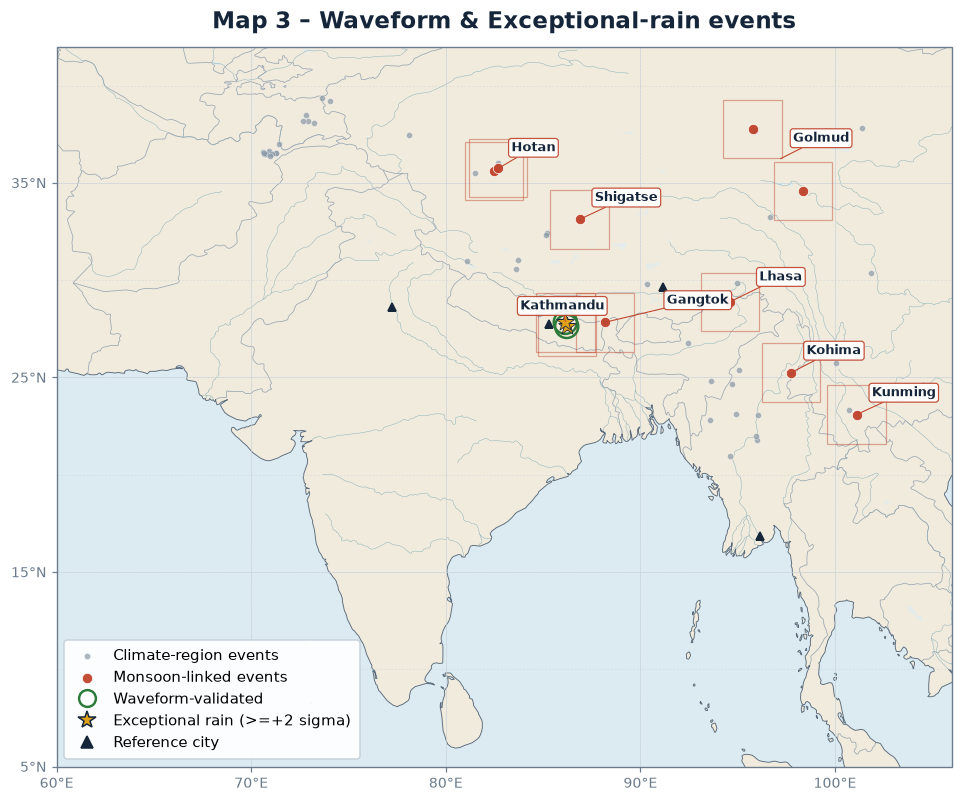

<GeoAxes: title={'center': 'Map 3 – Waveform & Exceptional-rain events'}>

In [18]:
plot_epicentre_map(df,
                   highlight_idx=waveform_ok,          # green rings
                   exceptional_idx=exceptional_idx,    # blue stars
                   title="Map 3 – Waveform & Exceptional-rain events")


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 5. Climatology precipitation: Extracting rainfall flux (era5_data)
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

**Why a 30-year baseline?** A seasonal total in millimetres only becomes meaningful once you
know what is *normal* for that place. Here we put each event's monsoon total in the context of its
own three-decade climatology and express it as a **standardised anomaly (z-score)**.

**Step by step**
- **Baseline.** For the same `3 deg x 3 deg` box we download the May-Sep ERA5 total for **every
  year 1991-2020** (the WMO-standard 30-year reference period). Results are cached per box.
- **Statistics.** From that series we compute the **mean (mu)** and **standard deviation (sigma)**.
- **Anomaly.** The event year becomes `z = (observed - mu) / sigma`: `z ~ 0` is an average monsoon,
  `z >= +2` an exceptionally wet year (top ~2.5%), `z <= -2` an exceptional drought.
- **Outputs per event:** `clim_mean_mm`, `clim_sigma_mm`, `monsoon_z`, plus a time-series plot with
  the +/-1 sigma / +/-2 sigma envelope and the event year marked.

> **Why this is the sounder severity measure.** Unlike the fixed bands in Section 4 (calibrated to
> all-India rainfall), the z-score judges each site against *itself*, so it works even in a normally
> dry box. It still describes *coincidence in time*, not a proven causal link - see the closing notes.


In [19]:
# This section needs three things from the cells above:
#   * event_df with the column 'monsoon_total_precipitation_mm'  (Section 3)
#   * the helper era5_monsoon_total(lat, lon, year)              (defined just below)
#   * a configured ~/.cdsapirc for the 1991-2020 downloads       (setup section)
# Each 3x3 deg box is built only once and cached in 'baseline_cache'.


In [20]:
def era5_monsoon_total(lat, lon, year):
    """Download (if needed) and return May-Sep ERA-5 total precipitation (mm)
    for a 3x3 deg box centred on (lat, lon). NetCDFs are cached in BASELINE_DIR.

    The cache filename includes lat/lon so that different epicentres in the same
    year do NOT collide on one file. Returns np.nan if the file cannot be
    produced or read (e.g. no CDS credentials).
    """
    area   = [lat + 1.5, lon - 1.5, lat - 1.5, lon + 1.5]  # N W S E
    months = [f"{m:02d}" for m in range(5, 10)]
    target = pathlib.Path(BASELINE_DIR) / f"era5_{round(lat,2)}_{round(lon,2)}_{year}_monsoon.nc"

    if not target.exists():
        if cds_client is None:
            print(f"   (no CDS client) cannot download baseline year {year}")
            return np.nan
        print(f"  downloading ERA-5 {year} -> {target.name}")
        try:
            cds_client.retrieve(
                "reanalysis-era5-single-levels-monthly-means",
                {"product_type": "monthly_averaged_reanalysis",
                 "variable": "total_precipitation",
                 "year": [str(year)],
                 "month": months,
                 "time": "00:00",
                 "area": area,
                 "data_format": "netcdf",
                 "download_format": "unarchived"},
                str(target))
        except Exception as e:
            print(f"   retrieve raised for {year} ({e})")
            if not target.exists():
                return np.nan

    try:
        ds = xr.open_dataset(target)
        total_mm = float(ds["tp"].sum() * 1000)   # m -> mm
        ds.close()
        return total_mm
    except Exception as e:
        print(f"   could not read {target.name}: {e}")
        return np.nan


In [21]:
from pathlib import Path
import pathlib


BASELINE_DIR = os.path.join(os.getcwd(), "epos_data", "era5_baseline")
os.makedirs(BASELINE_DIR, exist_ok=True) 

# Build 30-year baseline & z-score for 2015
# cache so identical boxes are done once
baseline_cache = {}

for i, row in tqdm(event_df.iterrows(),
                   total=len(event_df),
                   desc="30-yr climatology"):

    obs = row["monsoon_total_precipitation_mm"]
    if pd.isna(obs):
        continue                        # skip events without precipitation

    lat, lon = float(row["Epicentre lat"]), float(row["Epicentre lon"])
    epic_key = (round(lat,2), round(lon,2))   # key per grid box

    if epic_key not in baseline_cache:
        # build 1991-2020 series once
        series = [era5_monsoon_total(lat, lon, y) for y in range(1991, 2021)] # 
        μ, σ   = np.mean(series), np.std(series, ddof=1)
        baseline_cache[epic_key] = (μ, σ)

    μ, σ = baseline_cache[epic_key]
    z    = (obs - μ) / σ if σ else np.nan

    event_df.at[i, "clim_mean_mm"]   = μ
    event_df.at[i, "clim_sigma_mm"]  = σ
    event_df.at[i, "monsoon_z"]      = z

# quick peek
print(event_df[["Event idx","monsoon_total_precipitation_mm",
                "clim_mean_mm","clim_sigma_mm","monsoon_z"]])




30-yr climatology: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  7.10it/s]

   Event idx monsoon_total_precipitation_mm  clim_mean_mm  clim_sigma_mm  \
0         27                    5530.799866   6767.454084     834.068847   
1         28                    5229.846954   6415.719986     786.114519   

   monsoon_z  
0  -1.482676  
1  -1.508525  


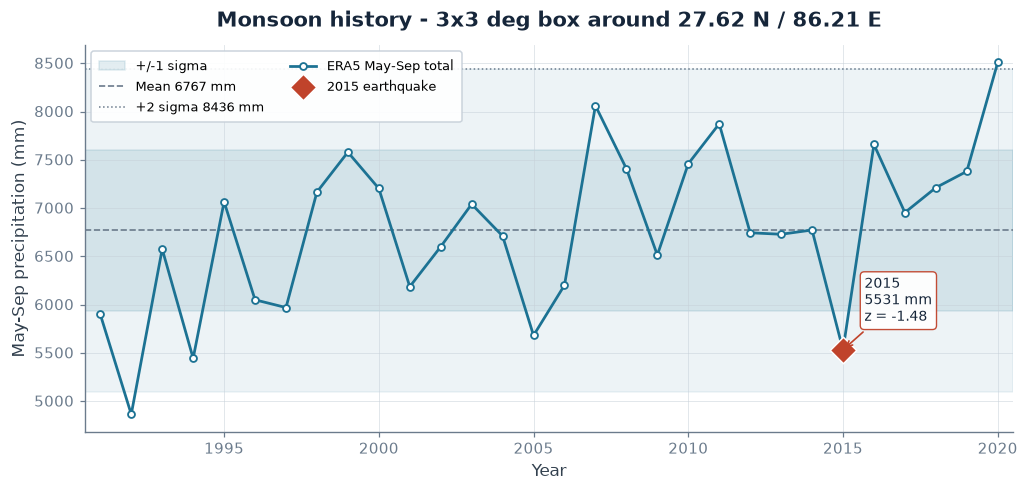

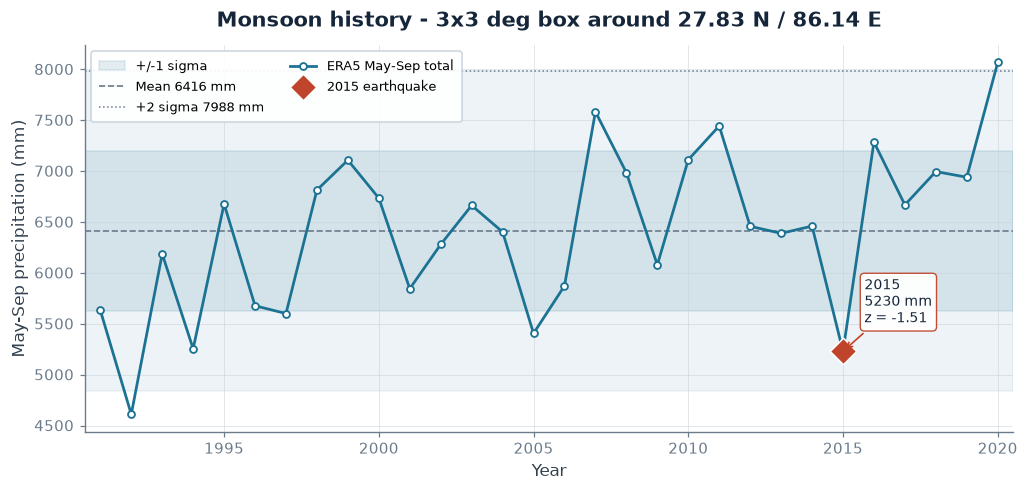

In [22]:
# ----------------------------------------------------------------------------
# Time-series context plot - 30-yr ERA5 monsoon totals (one figure per event).
# Uses the shared, presentation-ready helper plot_monsoon_timeseries().
# ----------------------------------------------------------------------------
years = list(range(1991, 2021))

for _, ev in event_df.dropna(subset=["monsoon_z"]).iterrows():
    lat, lon  = float(ev["Epicentre lat"]), float(ev["Epicentre lon"])
    mu, sigma = baseline_cache[(round(lat, 2), round(lon, 2))]
    series    = [era5_monsoon_total(lat, lon, y) for y in years]   # cached -> fast
    plot_monsoon_timeseries(
        years=years, series=series, mu=mu, sigma=sigma,
        obs_year=ev["Origin time"].year,
        obs_total=ev["monsoon_total_precipitation_mm"],
        z=ev["monsoon_z"], lat=lat, lon=lon,
    )


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 6. Build a multimodal pickle archiving
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

### Documentation for this section:

This section gathers all key outputs and intermediate data into a single
Python dictionary and saves it to a binary file using the 'pickle' module.
This allows for convenient archiving and later retrieval of the entire
analysis state, including DataFrames, raw seismic data, images , and references to
downloaded climate data.


The `pickle` module serializes Python objects into a byte stream, allowing
them to be written to a file and deserialized back into Python objects.
This is ideal for saving complex, heterogeneous data structures.

In [23]:
import pickle, gzip, io, hashlib, platform
import pickle, gzip, io, hashlib, platform
from datetime import datetime, timezone
from pathlib import Path

In [24]:
# Helper – Matplotlib-figure → PNG bytes

def fig2png_bytes(fig, dpi: int = 150) -> bytes:
    """Return a Matplotlib figure as compressed PNG bytes (no disk I/O)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    png = buf.getvalue()
    buf.close()
    return png

In [25]:
# Metadata block  (auto-filled, nothing hard-coded)

metadata = {
    "script_version"      : "clim-seis v1.0",
    "run_timestamp_utc"   : datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "python_version"      : platform.python_version(),
    "probable_flag_logic" : "depth ≤ 10 km & Mw ≥ 4.5 & keyword region & month 5-9",
    "waveform_ok_indices" : waveform_ok,              # e.g. [16, 21, 25, …]
    "n_events_validated"  : len(event_table),
}

In [26]:
figures_png: dict[str, bytes] = {}

if plt.get_fignums():                               # any figure still open?
    last_fig = plt.gcf()
    figures_png["map_wave_exc"] = fig2png_bytes(last_fig)

In [27]:
# Climate grids -- read each downloaded NetCDF once and store it in a dict.
# Key rule: 'event_<Event idx padded to 3>'. We call .load() so the data is
# materialised in memory and detached from the file handle, which makes the
# dataset safe to pickle in the archive cell below.

climate_grids: dict[str, xr.Dataset] = {}

for ev in event_table:
    evt_id = ev["Event idx"]
    year   = ev["Origin time"].year
    key    = f"event_{evt_id:03d}"

    # find a file that matches this event
    pattern  = f"era5_event_{evt_id}_{year}_monsoon*.nc"
    nc_files = list(Path(OUT_DIR_ERA5).glob(pattern))
    if not nc_files:
        continue  # nothing was downloaded (or it failed) for this event

    try:
        ds = xr.open_dataset(nc_files[0])
        climate_grids[key] = ds.load()   # materialise -> picklable
        ds.close()
    except Exception as err:
        print(f"   could not open {nc_files[0].name}: {err}")


In [28]:
# Assemble *all* outputs in one top-level dictionary

all_outputs = dict(
    metadata          = metadata,            # Textual data
    catalog_raw       = original_df,         # full CSV as loaded
    catalog_filtered  = event_df,            # only waveform-validated rows
    waveforms         = event_table,         # list[dict]   (raw traces & picks)
    climate_grids     = climate_grids,       # dict[str → xr.Dataset]
    figures_png       = figures_png,         # dict[str → PNG bytes]
    # empty slots for future modalities
    ml_models         = None,
    literature_cache  = [],
)



In [29]:
# Write the pickle with gzip compression

out_file = Path("clim_seis_multimodal.pkl.gz")
with gzip.open(out_file, "wb") as f:
    pickle.dump(all_outputs, f, protocol=pickle.HIGHEST_PROTOCOL)

sha = hashlib.sha256(out_file.read_bytes()).hexdigest()[:12]
print(f"Pickle archive written → {out_file}   (sha256:{sha})")



Pickle archive written → clim_seis_multimodal.pkl.gz   (sha256:dd41ef36e463)


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 7. Visual summary
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Two figures summarise the science and the processing pipeline of this notebook.

**Figure 1 — Physical mechanism.**

![Conceptual cross-section: monsoon rainfall loading and shallow seismicity](conceptual_mechanism.png)

*Intense monsoon rainfall infiltrates the surface, raises pore-fluid pressure and reduces the effective normal stress on shallow (< 10 km) faults, which can influence the timing of earthquakes. The cross-section illustrates the hypothesis with the 2009 Mₚ 7.6 Padang (West Sumatra) event; the selection filters and workflow stages used here are summarised on the right.*

**Figure 2 — Reproducible workflow.**

![Data-lineage diagram of the climate-context seismic pipeline](epos_workflow.png)

*End-to-end data lineage: from the EPOS / FDSN catalogue and GFZ waveforms together with ECMWF ERA5 precipitation, through event flagging, STA/LTA validation, absolute-band monsoon classification and a 30-year z-score climatology, to a single hash-stamped multimodal archive (`clim_seis_multimodal.pkl.gz`).*


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 8. Reference summary for Methods Section, Documentation, or Report
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

- Allen, R. V. (1978). Automatic earthquake recognition and timing from single traces.
  Bulletin of the Seismological Society of America, 68(5), 1521-1532.
  [No DOI provided in original context, standard reference for STA/LTA]
- Amos, C.B., et al. (2014), "Seasonal strain and microseismicity in the Himalaya induced by surface hydrology",
  Nature, 510, 496–499. [https://doi.org/10.1038/nature13202]
- Bettinelli, P., et al. (2008), "Seasonal surface loading and the modulation of seismicity in the Himalaya",
  Nature Geoscience, 1, 44–48. [https://doi.org/10.1038/ngeo251]
- Bookhagen, B. & Burbank, D.W. (2010), "Toward a tectonic geomorphology of the Himalaya and Tibet",
  Nature Geoscience, 3, 611–617. [https://doi.org/10.1038/ngeo907]
- Copernicus Climate Change Service (C3S) (2017): ERA5: Fifth generation of ECMWF atmospheric reanalyses
  of the global climate. Copernicus Climate Change Service Climate Data Store (CDS).
  (Accessed on 07-JUN-2025), [https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels-monthly-means?tab=overview]
- Craig, T. J., et al. (2017). Hydrological loading drives daily earthquake cycles in the Himalayas.
  Nature Communications, 8(1), 15696. [https://doi.org/10.1038/ncomms15696]
- India Meteorological Department (IMD) Glossary and FAQs on Monsoon (various dates, accessed via search results).
- Mayer, H., et al. (2014), "Influence of hydrological loading on seasonal variations in seismicity in the Himalaya",
  Earth Surface Dynamics, 2(2), 455–465. [https://doi.org/10.5194/esurf-2-455-2014]
- ObsPy Project (https://docs.obspy.org/)
- Pérez-Guillén, C., et al. (2022). Precipitation‐induced stress changes control seismicity in a dry, mountainous region.
  Geophysical Research Letters, 49(23), e2022GL100746. [https://doi.org/10.1029/2022GL100746]
- Sun, C., et al. (2020). Seasonal Modulations of Microseismicity in the Longmen Shan Thrust Belt, Eastern Tibetan Plateau.
  Journal of Geophysical Research: Solid Earth, 125(3), e2019JB018823. [https://doi.org/10.1029/2019JB018823]
- Trani, D. (2010). Automated Real-time Detection of Seismic Events.
  Masters thesis, Politecnico di Torino. [No DOI provided in original context, standard reference for STA/LTA]
- Turner, A.G. & Annamalai, H. (2012), "Climate change and the South Asian summer monsoon",
  Nature Climate Change, 2, 587–595. [https://doi.org/10.1038/nclimate1495]

